In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')










In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================
df = pd.read_csv('framingham.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (4240, 16)

First 5 rows:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYea


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 

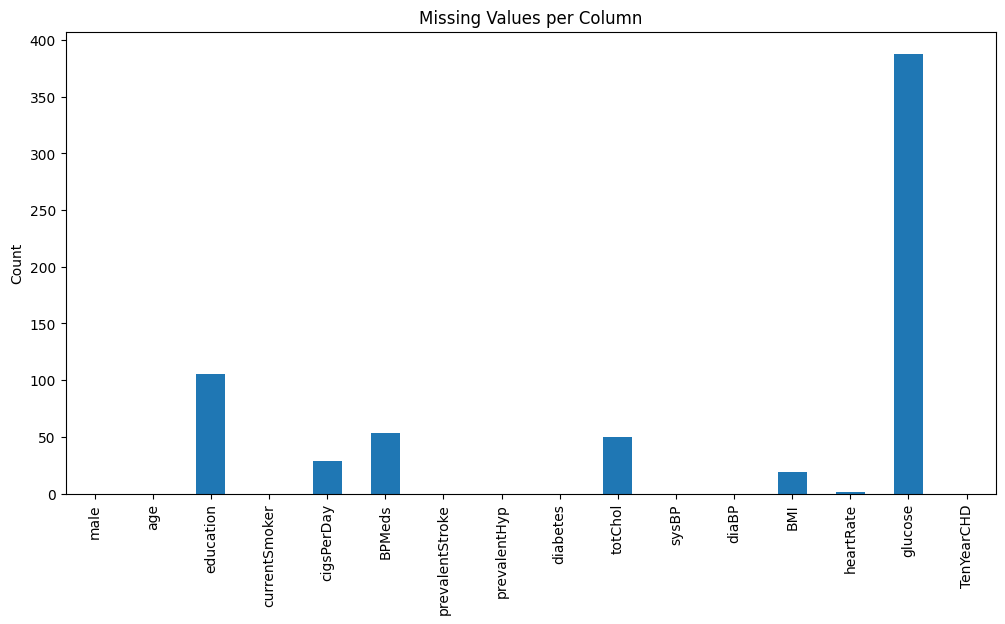


Target Distribution:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64
Imbalance Ratio: 5.58:1


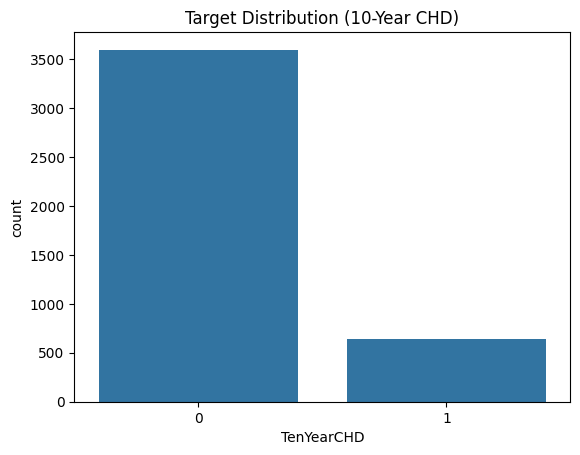

In [3]:
# ============================================================
# 3. EXPLORATORY DATA ANALYSIS
# ============================================================
print("\n=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

# Visualize missing values
plt.figure(figsize=(12,6))
df.isnull().sum().plot(kind='bar')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.show()

# Target distribution
target = 'TenYearCHD'
print(f"\nTarget Distribution:\n{df[target].value_counts()}")
print(f"Imbalance Ratio: {df[target].value_counts()[0]/df[target].value_counts()[1]:.2f}:1")

sns.countplot(x=target, data=df)
plt.title('Target Distribution (10-Year CHD)')
plt.show()


In [4]:
# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================
# Check missing percentages
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing Values (%):\n", missing_percent[missing_percent > 0])

# Drop rows with too many missing values? No, use imputation
# For numerical columns - fill with median (more robust than mean)
df.fillna(df.median(), inplace=True)

# Verify no missing values remain
print("\nMissing values after imputation:\n", df.isnull().sum().sum())


Missing Values (%):
 education     2.476415
cigsPerDay    0.683962
BPMeds        1.250000
totChol       1.179245
BMI           0.448113
heartRate     0.023585
glucose       9.150943
dtype: float64

Missing values after imputation:
 0


In [5]:
# ============================================================
# 5. FEATURE & TARGET SPLIT
# ============================================================
X = df.drop(target, axis=1)
y = df[target]

In [6]:
# ============================================================
# 6. TRAIN-TEST SPLIT (Stratified)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (3392, 15), Test shape: (848, 15)


In [7]:

# ============================================================
# 7. FEATURE SCALING
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# ============================================================
# 8. HANDLE IMBALANCE USING SMOTE
# ============================================================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE - Train distribution:\n{pd.Series(y_train_res).value_counts()}")


After SMOTE - Train distribution:
TenYearCHD
0    2877
1    2877
Name: count, dtype: int64


In [9]:
# ============================================================
# 9. DEFINE MODELS AND EVALUATION FUNCTION
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=3)
}

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CHD', 'CHD'])
    disp.plot()
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}


Model: Logistic Regression
Accuracy : 0.6675
Precision: 0.2524
Recall   : 0.6047
F1-Score : 0.3562

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.68      0.78       719
           1       0.25      0.60      0.36       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.57       848
weighted avg       0.81      0.67      0.71       848



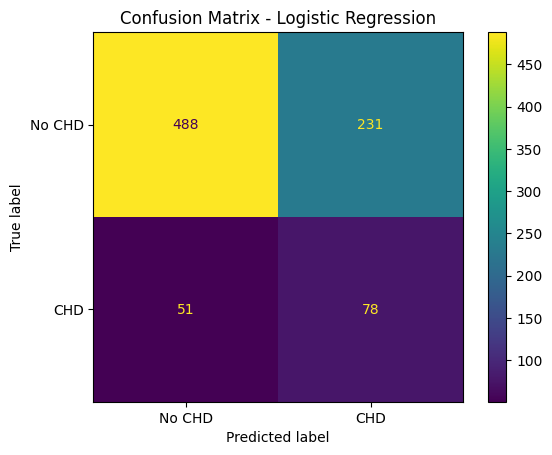


Model: Random Forest
Accuracy : 0.7936
Precision: 0.2500
Recall   : 0.1783
F1-Score : 0.2081

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88       719
           1       0.25      0.18      0.21       129

    accuracy                           0.79       848
   macro avg       0.55      0.54      0.54       848
weighted avg       0.77      0.79      0.78       848



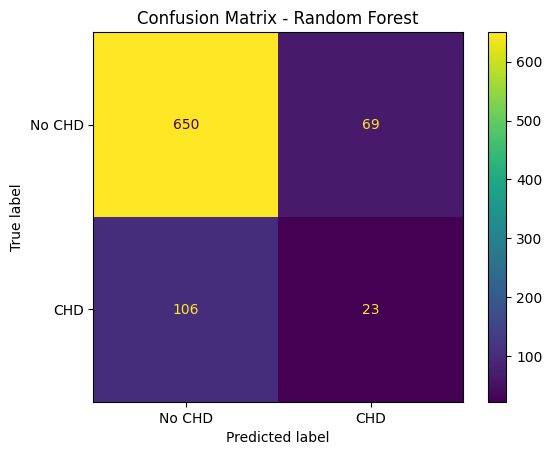


Model: SVM
Accuracy : 0.6769
Precision: 0.2325
Recall   : 0.4884
F1-Score : 0.3150

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.71      0.79       719
           1       0.23      0.49      0.32       129

    accuracy                           0.68       848
   macro avg       0.56      0.60      0.55       848
weighted avg       0.79      0.68      0.72       848



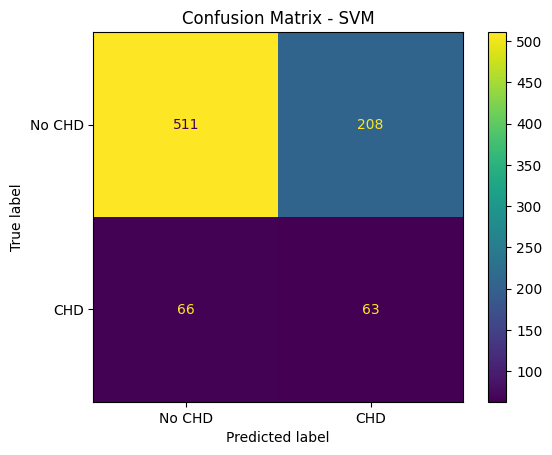


Model: XGBoost
Accuracy : 0.7571
Precision: 0.2308
Recall   : 0.2558
F1-Score : 0.2426

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86       719
           1       0.23      0.26      0.24       129

    accuracy                           0.76       848
   macro avg       0.55      0.55      0.55       848
weighted avg       0.77      0.76      0.76       848



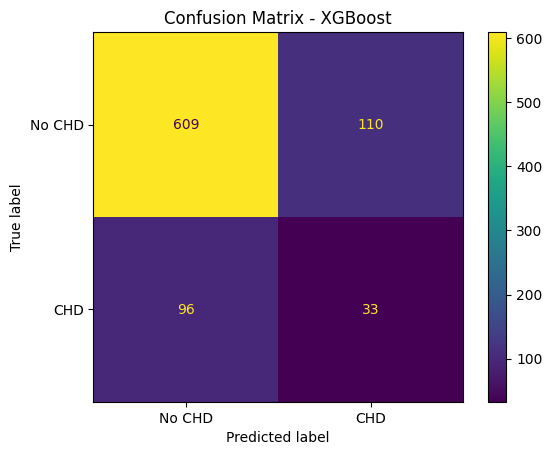

In [10]:


# ============================================================
# 10. TRAIN AND EVALUATE ALL MODELS
# ============================================================
results = {}
for name, model in models.items():
    results[name] = evaluate_model(model, X_train_res, y_train_res, X_test_scaled, y_test, name)



=== MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.667453   0.252427  0.604651  0.356164
Random Forest        0.793632   0.250000  0.178295  0.208145
SVM                  0.676887   0.232472  0.488372  0.315000
XGBoost              0.757075   0.230769  0.255814  0.242647


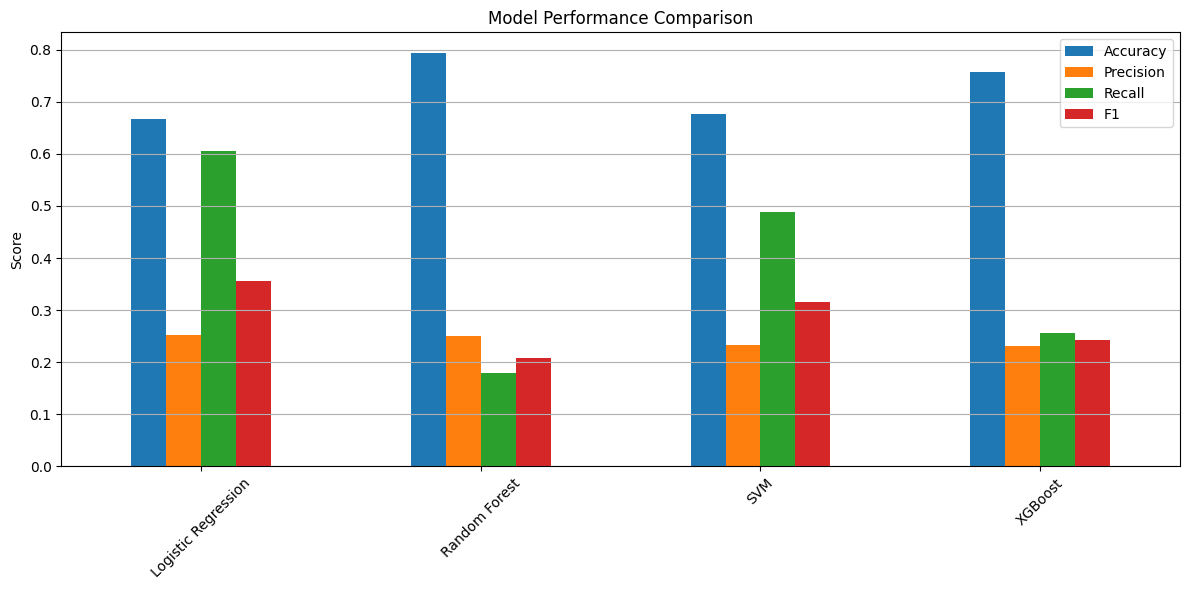

In [11]:
# ============================================================
# 11. COMPARE MODELS
# ============================================================
comparison_df = pd.DataFrame(results).T
print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(comparison_df)

# Visual comparison
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(12,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [12]:

# ============================================================
# 12. SELECT BEST MODEL (based on F1-Score)
# ============================================================
best_model_name = comparison_df['F1'].idxmax()
print(f"\n✅ Best model based on F1-Score: {best_model_name}")


✅ Best model based on F1-Score: Logistic Regression


In [13]:
# ============================================================
# 13. HYPERPARAMETER TUNING FOR BEST MODEL
# ============================================================
best_model = models[best_model_name]

# Define hyperparameter grids
if best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif best_model_name == 'SVM':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    }
else:  # XGBoost
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

# Create pipeline with SMOTE and classifier
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', best_model)
])

# GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid={'classifier__' + k: v for k, v in param_grid.items()},
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n🏆 Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1-Score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits

🏆 Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best cross-validation F1-Score: 0.3829



🎯 TUNED Logistic Regression PERFORMANCE
Accuracy : 0.6651
Precision: 0.2508
Recall   : 0.6047
F1-Score : 0.3545

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.68      0.77       719
           1       0.25      0.60      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.81      0.67      0.71       848



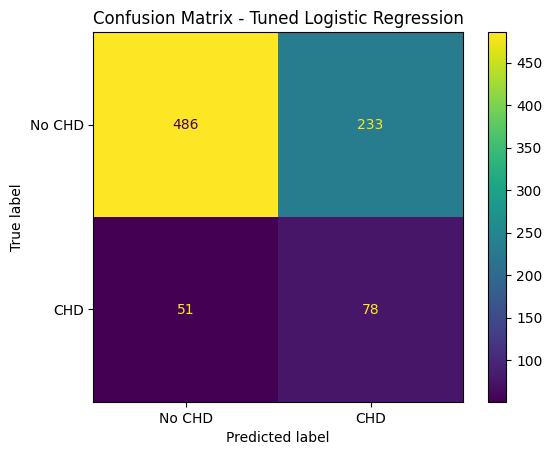

In [14]:
# ============================================================
# 14. EVALUATE TUNED BEST MODEL ON TEST SET
# ============================================================
best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test_scaled)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\n{'='*60}")
print(f"🎯 TUNED {best_model_name} PERFORMANCE")
print(f"{'='*60}")
print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1-Score : {f1_tuned:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

# Confusion Matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No CHD', 'CHD'])
disp_tuned.plot()
plt.title(f'Confusion Matrix - Tuned {best_model_name}')
plt.show()




In [15]:
# ============================================================
# 15. SAVE MODELS (OPTIONAL)
# ============================================================
import joblib
joblib.dump(best_tuned_model, 'best_framingham_model.pkl')
joblib.dump(scaler, 'scaler_framingham.pkl')
print("\n💾 Best model saved as 'best_framingham_model.pkl'")
print("💾 Scaler saved as 'scaler_framingham.pkl'")



💾 Best model saved as 'best_framingham_model.pkl'
💾 Scaler saved as 'scaler_framingham.pkl'


In [16]:
# ============================================================
# 16. FEATURE IMPORTANCE (if applicable)
# ============================================================
if best_model_name in ['Random Forest', 'XGBoost']:
    try:
        # Get the classifier from pipeline
        clf = best_tuned_model.named_steps['classifier']
        importances = clf.feature_importances_
        feature_names = X.columns

        # Create DataFrame
        feat_imp_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        # Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature')
        plt.title(f'Top 15 Feature Importances - {best_model_name}')
        plt.tight_layout()
        plt.show()

        print("\n📊 Top 10 Features:")
        print(feat_imp_df.head(10))
    except:
        pass

print("\n✅ Assignment Complete! All results generated successfully.")


✅ Assignment Complete! All results generated successfully.
